## **Exploratory Data Analysis**

Exploratory Data Analysis (EDA) is used to understand the structure, patterns, and relationships within a dataset before building any models. It helps identify key trends, detect anomalies, and uncover important factors that may influence the target variable. In this project, EDA was essential for revealing customer behavior patterns, such as the impact of contract type, tenure, and service usage on churn. These insights guided feature engineering and modeling decisions, ensuring that the analysis was both data-driven and aligned with business objectives.

<br>

#### **1. Setup & Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Ferdinand Taslim\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


<br>

#### **2. Load Dataset**

In [2]:
df = pd.read_excel("../data/raw/Customer_Churn_Raw.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


<br>

#### **3. Basic Overview**

In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

df.info()

df.describe()

Shape: (7043, 33)

Columns:
 Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   Ci

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


<br>

#### **4. Initial Cleaning**

In [4]:
# Drop unnecessary columns
df.drop(columns=['CustomerID', 'Count', 'Lat Long', 'Latitude', 'Longitude'], inplace=True, errors='ignore')

# Convert Total Charges to numeric
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

# Fix Zip Code
df['Zip Code'] = df['Zip Code'].astype('object')

# Check missing values
df.isnull().sum()

Country                 0
State                   0
City                    0
Zip Code                0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

<br>

#### **5. Handle Missing Values**

In [5]:
# Fill missing Total Charges with 0 
df['Total Charges'] = df['Total Charges'].fillna(0)

<br>

#### **6. Target Variable Analysis**

In [6]:
df['Churn Label'].value_counts()
df['Churn Label'].value_counts(normalize=True)

Churn Label
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

<br>

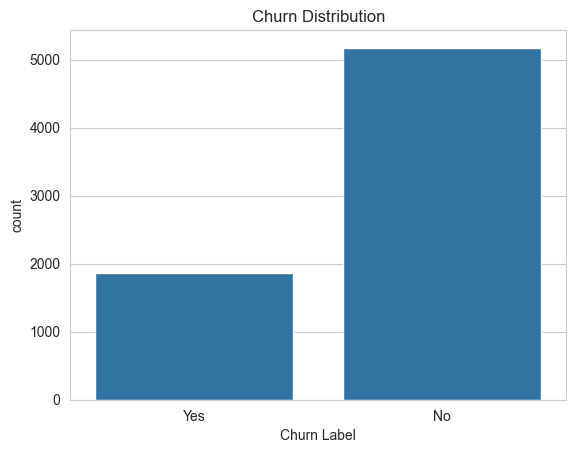

In [7]:
# Visualization
sns.countplot(data=df, x='Churn Label')
plt.title("Churn Distribution")
plt.show()

<br>

#### **7. Churn by Contract Type**

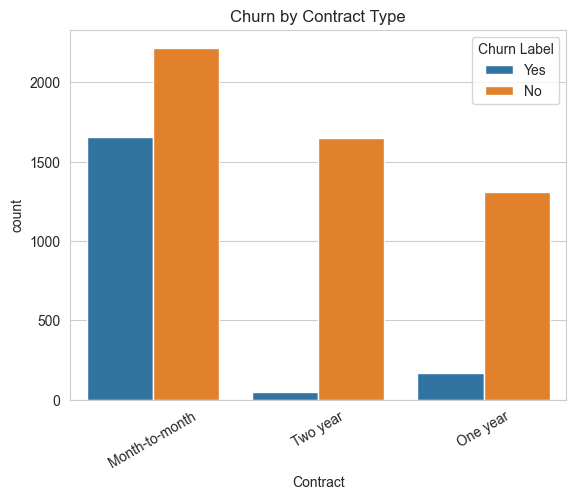

In [8]:
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title("Churn by Contract Type")
plt.xticks(rotation=30)
plt.show()

**Insight:** Month-to-month contracts are expected to have higher churn rates.

<br>

#### **8. Tenure vs Churn**

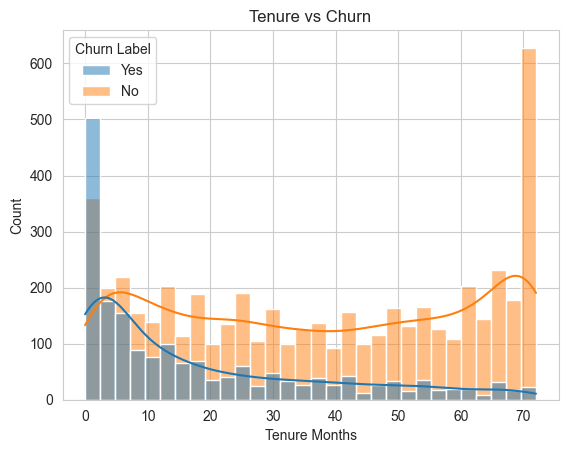

In [9]:
sns.histplot(data=df, x='Tenure Months', hue='Churn Label', bins=30, kde=True)
plt.title("Tenure vs Churn")
plt.show()

**Insight:** Customers with shorter tenure tend to churn more.

<br>

#### **9. Monthly Charges vs Churn**

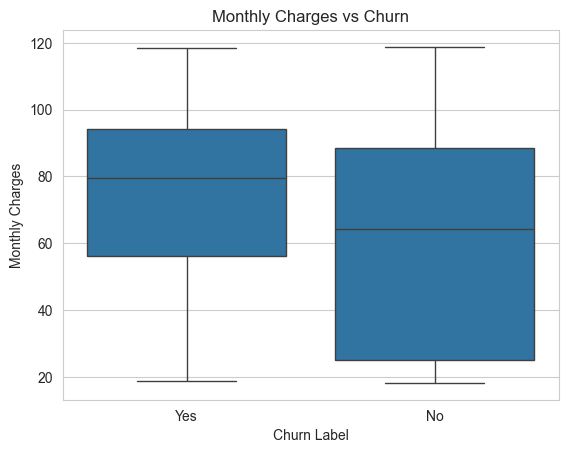

In [10]:
sns.boxplot(data=df, x='Churn Label', y='Monthly Charges')
plt.title("Monthly Charges vs Churn")
plt.show()

**Insight:** Customers with higher monthly charges are more likely to churn, suggesting price sensitivity or perceived lack of value.

<br>

#### **10. Internet Service vs Churn**

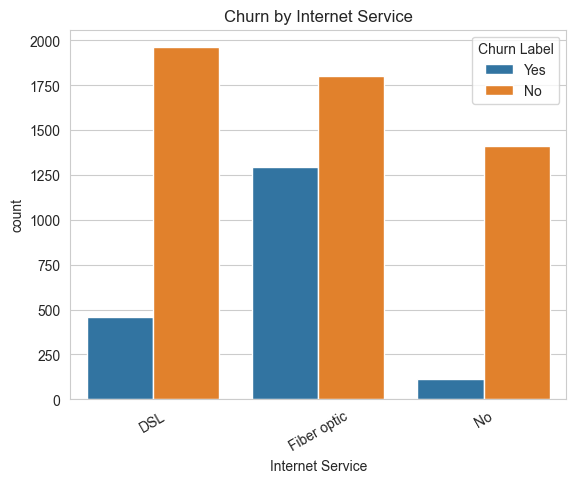

In [11]:
sns.countplot(data=df, x='Internet Service', hue='Churn Label')
plt.title("Churn by Internet Service")
plt.xticks(rotation=30)
plt.show()

**Insight:** Customers using fiber optic services have significantly higher churn rates, indicating potential dissatisfaction despite premium offerings.

<br>

#### **11. CLTV vs Churn**

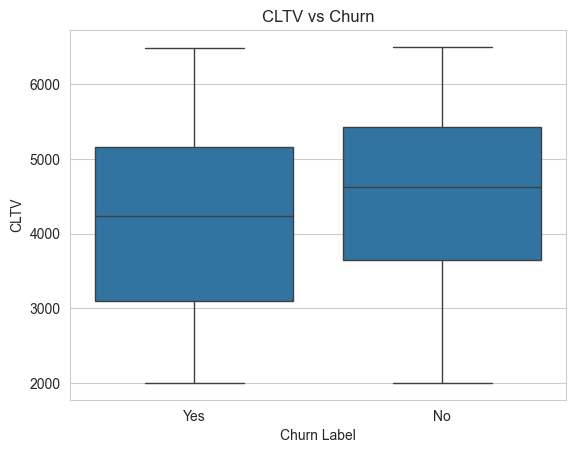

In [12]:
sns.boxplot(data=df, x='Churn Label', y='CLTV')
plt.title("CLTV vs Churn")
plt.show()

**Insight:** While retained customers generally have higher lifetime value, a segment of high-CLTV customers is still churning, representing a critical revenue risk.

<br>

#### **12. Correlation Heatmap**

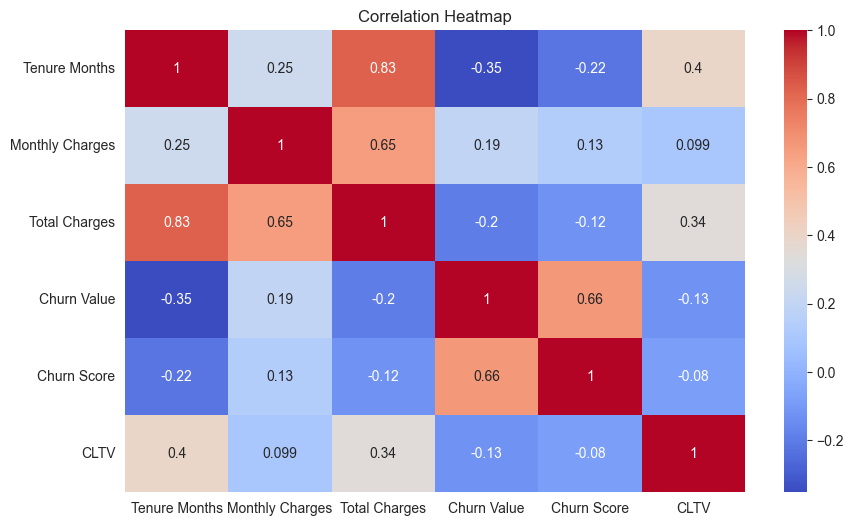

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Insight:** Customer tenure is one of the strongest predictors of churn, with newer customers significantly more likely to leave. Additionally, existing churn scoring systems show strong predictive capability.

<br>

#### **13. Quick Feature Observations**

In [14]:
df.groupby('Internet Service')['Churn Value'].mean().sort_values(ascending=False)

Internet Service
Fiber optic    0.418928
DSL            0.189591
No             0.074050
Name: Churn Value, dtype: float64

**Insight:** Fiber optic customers have the highest churn rate at ~42%, more than double that of DSL users (~19%), indicating potential dissatisfaction with premium service offerings.

<br>

In [15]:
df.groupby('Contract')['Churn Value'].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn Value, dtype: float64

**Insight:** Customers on month-to-month contracts have an extremely high churn rate (~43%), compared to just ~3% for two-year contracts, making contract type one of the strongest predictors of churn.

<br>

#### **14. Save File**

In [16]:
df.to_csv("../data/raw/Post_EDA.csv", index=False)

<br><br>

### **Key Insights**

**1. Contract Type is the Strongest Driver of Churn**

Customers on **month-to-month contracts** exhibit the highest churn rate (**~43%**), compared to significantly lower rates for one-year (**~11%**) and two-year contracts (**~3%**). This indicates that a lack of long-term commitment strongly increases churn risk.

**2. Fiber Optic Customers Have Elevated Churn Risk**

Customers using **fiber optic internet** show a churn rate of **~42%**, more than double that of DSL users (**~19%**) and significantly higher than customers without internet service (**~7%**). This suggests potential dissatisfaction with premium services, possibly due to pricing, performance, or unmet expectations.

**3. Customer Tenure is a Key Retention Indicator**

Customers with **shorter tenure** are significantly more likely to churn, while long-term customers demonstrate much higher retention. This highlights the importance of early-stage customer engagement and onboarding.

**4. Higher Monthly Charges Contribute to Churn**

Customers with **higher monthly charges** tend to churn more frequently, indicating price sensitivity or a perceived lack of value for the cost.

**5. High-Value Customers Are Still at Risk**

While retained customers generally have higher **Customer Lifetime Value (CLTV)**, a notable portion of high-value customers still churn. This represents a critical business risk, as losing these customers has a disproportionate impact on revenue.

**6. High-Risk Customer Segment Identified**

The highest-risk segment consists of:
* **Fiber optic users**
* **Month-to-month contracts**
* **Shorter tenure**

These customers should be prioritized for targeted retention strategies.

<br>

### **Business Implications**

* **Promote long-term contracts** through incentives and strategic pricing.
* **Investigate and improve** the fiber optic service experience to address dissatisfaction.
* **Focus retention efforts** specifically on early-stage customers (onboarding).
* **Target high-value customers** with personalized retention campaigns.
* **Optimize pricing strategies** to improve the overall perceived value of the services.